# 실험14 — 선수 피처 조합 탐색과 과거 데이터 진단

## 선택 결과

선수 피처 **123개 조합**을1개 seed로 탐색하고, 상위 후보와 비교 기준 **14개 조합**을3개 seed 확률 앙상블로 재확인했다. 모두2025년 시간순 검증123시리즈만 사용했다.

선택한 **12피처**: 최근 승률, 15분 골드 차이, 15분 CS 차이, 분당 킬, 분당 데스, 분당 어시스트, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 분당 시야 점수, 기록량.
제외한 피처: 15분 경험치 차이.
구조: `12→8→4`, 포지션별 `4→2→1` 합산. 입력 수만 달라지고 나머지 A 구조는 같다.

조합 검증 점수는 **81/123 = 65.85%**, log loss 0.6480. 이것은 조합 선택에 사용한 점수이므로 독립 성능이 아니다.
2025에서 추가로 선택한 학습 연도 구성은 **선택 조합 / 2023~25**. 이 고정 후보의2026 회고 결과는 **115/186 = 61.83%**, 기존 A 대비 **-3시리즈**다.

## 탐색 범위와 평가 규칙

- 기존13개 선수 피처를 대상으로 승률·기록량 / 라인전15분 / KDA / 피해량 / 경제력 / 시야의6개 그룹을 만들고, 비어 있지 않은 그룹 조합63개를 모두 평가했다.
- 개별 피처1개만 쓰는13개 조합과1개씩 제거하는13개 조합을 추가했다. 중복 제거 후 첫 단계87개.
- seed42로 평가한 상위3개 조합에서 각 피처를 하나씩 추가/제거하는 이웃 조합을 탐색했다.
- 최종 screening 상위12개와 전체13개·기존 XP제거 기준을3개 seed로 재확인했다. 세트 확률을 평균한 후 시리즈 확률로 바꿨다.
- 정확도 우선, 동점 시 log loss, 다시 동점이면 피처 수로 정렬했다.
- **13개 피처의8,191개 전체 조합을 전수 탐색한 것은 아니다. 이번 탐색에서 가장 좋은 조합이다.** 한 seed의 screening에서 제외된 안정적인 조합이 있을 수 있다.
-2025 날짜 기준40→60%,60→80%,80→100%의3개 외부 구간. 각 구간보다 앞선 학습 데이터 내부에서만 epoch를 선택하고 재학습했다. 초기 가중치는 유지한 입력끼리 일치시켰다.
-2025 검증 자료를 여러 후보 선택에 반복 사용했으므로 검증 최고값은 낙관적이다.2026도 프로젝트에서 반복 열람한 회고 평가이며 untouched test가 아니다.

## 상위 조합 — 3 seed 확인 결과

| 피처 수 | 사용 피처 | 2025 정답 | 정확도 | Log loss |
| --- | --- | --- | --- | --- |
| 12 | 최근 승률, 15분 골드 차이, 15분 CS 차이, 분당 킬, 분당 데스, 분당 어시스트, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 분당 시야 점수, 기록량 | 81/123 | 65.85% | 0.6480 |
| 2 | 최근 승률, 기록량 | 79/123 | 64.23% | 0.6521 |
| 10 | 최근 승률, 15분 골드 차이, 15분 경험치 차이, 15분 CS 차이, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 분당 시야 점수, 기록량 | 79/123 | 64.23% | 0.6577 |
| 13 | 최근 승률, 15분 골드 차이, 15분 경험치 차이, 15분 CS 차이, 분당 킬, 분당 데스, 분당 어시스트, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 분당 시야 점수, 기록량 | 79/123 | 64.23% | 0.6607 |
| 9 | 최근 승률, 15분 골드 차이, 15분 CS 차이, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 분당 시야 점수, 기록량 | 78/123 | 63.41% | 0.6305 |
| 5 | 최근 승률, 15분 경험치 차이, 15분 CS 차이, 분당 시야 점수, 기록량 | 76/123 | 61.79% | 0.6428 |
| 9 | 최근 승률, 15분 골드 차이, 15분 경험치 차이, 15분 CS 차이, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 기록량 | 76/123 | 61.79% | 0.6476 |
| 10 | 최근 승률, 15분 골드 차이, 15분 경험치 차이, 15분 CS 차이, 분당 킬, DPM, 피해 점유율, 획득 골드 점유율, CSPM, 기록량 | 76/123 | 61.79% | 0.6550 |

## 학습 연도와 진단 조건 — 2025 검증

| 구성 | 정답 | 정확도 | Log loss | AUC |
| --- | --- | --- | --- | --- |
| 기존13 / 2025 | 79/123 | 64.23% | 0.6607 | 0.6706 |
| 기존13 / 2023~25 동일 가중치 | 79/123 | 64.23% | 0.6299 | 0.6919 |
| 기존13 / 과거 추가 + 2025 표준화 | 78/123 | 63.41% | 0.6362 | 0.6892 |
| 기존13 / 과거 추가 + 최근 가중치 | 76/123 | 61.79% | 0.6298 | 0.6988 |
| 기존13 / 과거 추가 + 학습 횟수 맞춤 | 81/123 | 65.85% | 0.6524 | 0.6772 |
| 선택 조합 / 2025 | 81/123 | 65.85% | 0.6480 | 0.6892 |
| 선택 조합 / 2024~25 | 78/123 | 63.41% | 0.6282 | 0.6900 |
| 선택 조합 / 2023~25 | 81/123 | 65.85% | 0.6262 | 0.6890 |

학습 연도 선택은 `selected_*` 세 구성 안에서만 수행했다. 진단 조건은 원인 후보를 비교하기 위해 미리 정했으며,2026 점수를 보고 최종 모델을 고르는 데 사용하지 않았다.

## 고정한 후보의2026 회고 결과

| 구성 | 정답 | 정확도 | Log loss | AUC |
| --- | --- | --- | --- | --- |
| 기존13 / 2025 | 118/186 | 63.44% | 0.6754 | 0.6484 |
| 기존13 / 2023~25 동일 가중치 | 110/186 | 59.14% | 0.6811 | 0.6358 |
| 기존13 / 과거 추가 + 2025 표준화 | 111/186 | 59.68% | 0.6792 | 0.6330 |
| 기존13 / 과거 추가 + 최근 가중치 | 109/186 | 58.60% | 0.6822 | 0.6352 |
| 기존13 / 과거 추가 + 학습 횟수 맞춤 | 110/186 | 59.14% | 0.6741 | 0.6363 |
| 선택 조합 / 2025 | 106/186 | 56.99% | 0.6688 | 0.6427 |
| 선택 조합 / 2024~25 | 109/186 | 58.60% | 0.6718 | 0.6392 |
| 선택 조합 / 2023~25 | 115/186 | 61.83% | 0.6776 | 0.6463 |

평가 기간: 2026-01-14 08:13:43 ~ 2026-09-12 05:21:16,186시리즈. 첫 세트 명단과 그 시점 이전 통계만 사용하고, 독립·동일 세트 승률을 가정해 Bo3/Bo5로 변환한다.

## 데이터가 늘면 왜 떨어질 수 있나 — 이번에 확인한 내용

### 1. 학습 표본 수와 목표 시즌의 비중은 다르다

2025만555세트를 학습할 때 목표 시즌 비중은100%다.2023의487세트와2024의482세트를 동일하게 섞으면2025 비중은 **36.42%**로 줄어든다. 표본 수는1,524개로 늘지만 최적화하는 손실은 과거 두 시즌의 영향을 더 많이 받는다.

선수 입력은 기존2025/2026과 동일하게 유지했다.2023·2024 입력은 각 연도 내부 rolling 기록이다. 이번 진단은 추가 표본을 섞는 효과이며,2024 기록으로2025 시즌 초 선수 이력을 보강하는 효과는 포함하지 않는다.

최근 가중치 진단은2023=.25,2024=.5,2025=1로 고정했고, scaler는 원래 pooled 상태를 유지했다.2025의 손실 가중치 비중은60.47%가 된다.2026 정답은 동일 가중치 **110개 → 109개**였다. 이 한 가지 가중치 설정의 결과로 모든 시간 가중치 방식을 일반화할 수 없다.

### 2. 표준화 기준과 선수 통계 분포가 달라진다

포지션별로2023/2024 평균이2025 평균에서 얼마나 떨어져 있는지2025 표준편차 단위로 계산했다. 다음은 각 연도에서 평균 절대 이동이 큰5개 피처다.

| 연도 | 피처 | 포지션 평균 절대 이동 / 2025 표준편차 |
| --- | --- | --- |
| 2023 | DPM | 1.250 |
| 2023 | 분당 시야 점수 | 0.970 |
| 2023 | CSPM | 0.947 |
| 2023 | 획득 골드 점유율 | 0.751 |
| 2023 | 분당 어시스트 | 0.749 |
| 2024 | CSPM | 1.257 |
| 2024 | 분당 시야 점수 | 0.963 |
| 2024 | 획득 골드 점유율 | 0.870 |
| 2024 | DPM | 0.642 |
| 2024 | 피해 점유율 | 0.517 |

예를 들어 정글 선수의 과거 평균 DPM은2023년 약299,2024년342,2025년434였다. 전체 파일에서 같은 포지션의 피처 평균을 비교한 값이다. 입력 분포가 달라진 채 학습 표본을 섞는다는 구체적인 예다.

이는 입력 분포 차이의 관측 증거다. 패치, 로스터, 리그 운영 중 무엇이 차이를 만들었는지 분리 검증한 것은 아니다. 나머지를 유지하고 결측 보충·표준화 기준만2025로 제한한 결과는 **110개 → 111개**였다. 이 진단은 전처리의 영향을 비교하며 원본 게임 환경 변화 전체를 제거하는 실험은 아니다.

### 3. 학습 횟수 선택도 크게 바뀐다

| 구성 | seed42 | seed43 | seed44 |
| --- | --- | --- | --- |
| 기존13 / 2025 | 8 | 7 | 77 |
| 기존13 / 2023~25 동일 가중치 | 1 | 2 | 67 |
| 기존13 / 과거 추가 + 2025 표준화 | 1 | 8 | 69 |
| 기존13 / 과거 추가 + 최근 가중치 | 1 | 2 | 66 |
| 기존13 / 과거 추가 + 학습 횟수 맞춤 | 8 | 7 | 77 |
| 선택 조합 / 2025 | 25 | 37 | 78 |
| 선택 조합 / 2024~25 | 58 | 1 | 69 |
| 선택 조합 / 2023~25 | 20 | 1 | 67 |

기존13/2025는8·7·77 epoch, 기존13/2023~25는1·2·67 epoch가 선택됐다. 후자는 두 seed가 매우 이른 시점에서 멈춘 모델로 최종 재학습됐다. 최대 epoch를500으로 지정했다고500번 학습된 것은 아니다. validation33시리즈에서 확률 손실로 epoch를 고르기 때문이다.

과거 데이터를 섞되 학습 횟수를2025-only 기준과 동일하게 맞춘 진단은 **110개 → 110개**였다.2025 외부fold에서도 해당fold의 과거2025 자료로 선택한 epoch만 가져와 사용했다.2026 점수로 학습 횟수를 고른 것은 아니다.

이번 세 통제 실험은 입력·가중치·학습 종료 정책을 각각 바꾼 관측 비교다. 여러 요인이 상호작용할 수 있어 전체 정확도 하락을 원인별 퍼센트로 분해하거나 하나의 확정 원인으로 선언하지 않는다.

관측상 표준화 변경은1개 회복, 최근 가중치는1개 하락, 학습 횟수 맞춤은 정답 수 동일이었다. 따라서 조기 종료나 표준화 하나가 정확도 하락의 전부라는 근거는 얻지 못했다. 학습 횟수를 맞추면 log loss는0.6811→0.6741로 개선됐다. 확률의 품질과0.5 기준 승자 정확도가 서로 다르게 움직이는 실제 사례다.

### 4. 과거와 최근 손실의 학습 방향도 점검했다

`gradient_diagnostics.csv`에는 같은 모델·2025 scaler에서 각 과거 연도와2025의 손실 gradient 사이 cosine을 저장했다. 초기 상태와2025-only 학습 후를 seed별로 비교한다. 음수는 그 지점에서 한쪽 손실을 줄이는 작은 이동이 다른 쪽 손실과 충돌할 수 있다는 뜻이다. 국소적인 진단이며2026 일반화 저하의 인과 증명은 아니다.

실제 측정한12개 cosine은 모두 양수(0.343~0.965)였다. 따라서 이번 측정에서 과거와2025의 학습 gradient가 반대 방향이라는 증거는 나오지 않았다. 데이터 분포 차이는 확인했지만 성능 하락의 단일 원인은 아직 특정하지 못했다.

## 재현 및 산출물

- 테스트10개 통과. 동일 가중치 학습을 기존 구현과 비교했고, baseline/pooled 예측을 실험13과1e-6 이내로 재현했다.
- 예비 실행에서 동일 가중치에도 weighted-sum BCE를 사용하자 float32 누적 차이로 기준 CV가79→80개로 달라져 폐기했다. 수정본은 원래 mean BCE 경로와 파라미터가 정확히 일치하는지 테스트하고, 전체 기준 CV79/123 재현 후 탐색했다. 예비 기록은 `14_player_subset_search_initial_numeric_audit/`에 분리했으며 선택 근거로 사용하지 않는다.
- 평가 전 선택·epoch·가중치 고정,2025 입력 불변, 팀 순서 대칭, 체크포인트 불변 확인.
- `python -m backend.training.player_subset_search`
- `python -m backend.training.report_player_subset_search`
- 검색 결과는 `screening_2025.json`, `confirmation_2025.json`, `search_cache/`에 저장. 선택 결과는 `selection_lock.json`, 가중치/scaler는 `frozen_2025.joblib`.
- 온라인 모델이나 기존 연구 결과를 덮어쓰지 않았다.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
RESULTS = Path('/Users/seungyunmok/Developer/LOL_ML/notebook/experiments/14_player_subset_search')
evaluation = pd.read_csv(RESULTS/'evaluation_2026.csv')
confirmation = pd.DataFrame(json.loads((RESULTS/'confirmation_2025.json').read_text()))
display(confirmation[['inputs','features','correct','accuracy','log_loss']])
display(evaluation)

,inputs,features,correct,accuracy,log_loss
0,12,"[past_result, past_golddiffat15, past_csdiffat...",81,0.658537,0.647959
1,2,"[past_result, history_fraction]",79,0.642276,0.652120
2,10,"[past_result, past_golddiffat15, past_xpdiffat...",79,0.642276,0.657690
3,13,"[past_result, past_golddiffat15, past_xpdiffat...",79,0.642276,0.660730
4,9,"[past_result, past_golddiffat15, past_csdiffat...",78,0.634146,0.630521
5,5,"[past_result, past_xpdiffat15, past_csdiffat15...",76,0.617886,0.642798
6,9,"[past_result, past_golddiffat15, past_xpdiffat...",76,0.617886,0.647608
7,10,"[past_result, past_golddiffat15, past_xpdiffat...",76,0.617886,0.654952
8,9,"[past_result, past_golddiffat15, past_xpdiffat...",76,0.617886,0.659174
9,9,"[past_result, past_golddiffat15, past_xpdiffat...",76,0.617886,0.669007


,candidate,selected_on_2025,n,correct,mean_abs_distance_from_50,accuracy,roc_auc,log_loss,brier_score,probability_min,probability_max
0,reference_2025,False,186,118,0.033324,0.634409,0.648358,0.675368,0.241152,0.416616,0.608987
1,pooled_2023_2025,False,186,110,0.024282,0.591398,0.635754,0.681125,0.244002,0.435197,0.570358
2,pooled_2025_scaler,False,186,111,0.029383,0.596774,0.632979,0.679171,0.243034,0.418721,0.592274
3,pooled_recent_weights,False,186,109,0.021872,0.586022,0.635176,0.682221,0.244547,0.440396,0.564595
4,pooled_matched_epochs,False,186,110,0.041243,0.591398,0.636332,0.674125,0.240549,0.395128,0.623767
5,selected_2025,False,186,106,0.049479,0.569892,0.642692,0.668826,0.237988,0.376665,0.656775
6,selected_2024_2025,False,186,109,0.042441,0.586022,0.639223,0.671815,0.239433,0.387612,0.632418
7,selected_2023_2025,True,186,115,0.028455,0.618280,0.646277,0.677621,0.242265,0.427516,0.588203


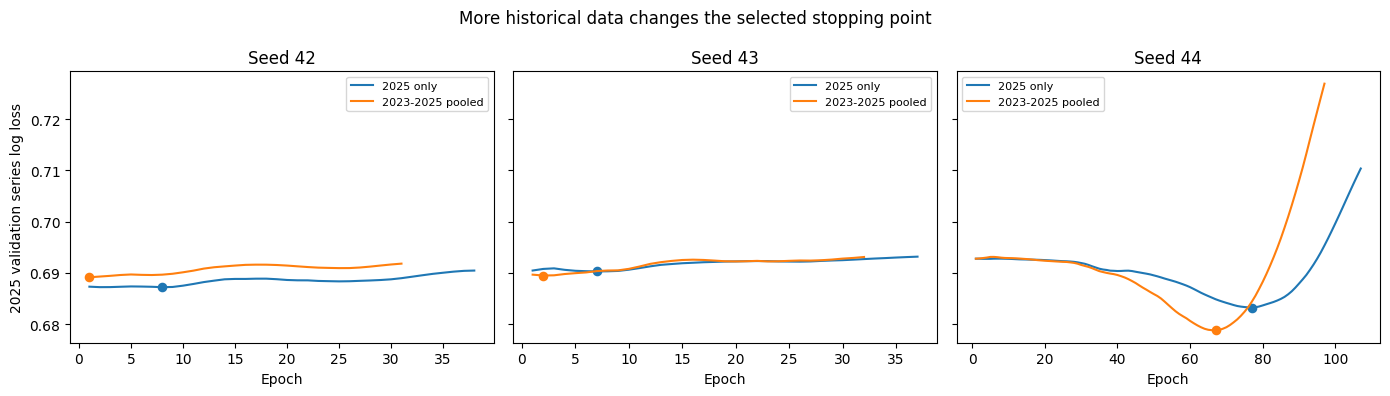

In [2]:
curves = pd.read_csv(RESULTS/'early_stopping_curves_2025.csv')
fig,axes=plt.subplots(1,3,figsize=(14,4),sharey=True)
for ax,seed in zip(axes,[42,43,44]):
    for name,label in [('reference_2025','2025 only'),('pooled_2023_2025','2023-2025 pooled')]:
        g=curves[(curves.candidate==name)&(curves.seed==seed)]
        ax.plot(g.epoch,g.validation_series_log_loss,label=label)
        best=g.loc[g.validation_series_log_loss.idxmin()]
        ax.scatter(best.epoch,best.validation_series_log_loss,s=35)
    ax.set_title(f'Seed {seed}'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
axes[0].set_ylabel('2025 validation series log loss')
fig.suptitle('More historical data changes the selected stopping point')
fig.tight_layout(); fig.savefig(RESULTS/'early_stopping.png',dpi=160); plt.show()

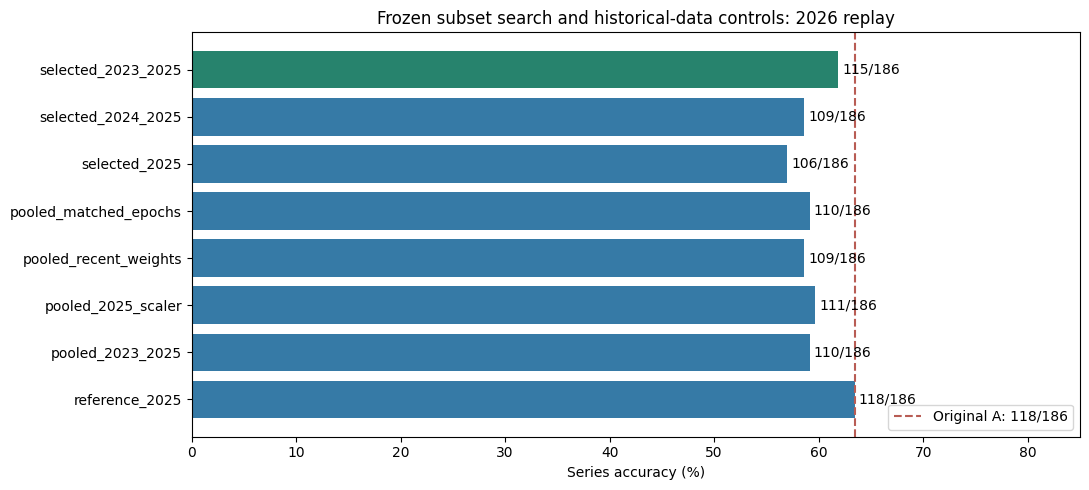

In [3]:
fig,ax=plt.subplots(figsize=(11,5))
colors=['#367aa6' if not r.selected_on_2025 else '#27836d' for r in evaluation.itertuples()]
ax.barh(evaluation.candidate,evaluation.accuracy*100,color=colors)
ax.axvline(118/186*100,color='#b85c54',linestyle='--',label='Original A: 118/186')
for i,r in enumerate(evaluation.itertuples()): ax.text(r.accuracy*100+.4,i,f'{r.correct}/186',va='center')
ax.set_xlim(0,85); ax.set_xlabel('Series accuracy (%)'); ax.legend(loc='lower right')
ax.set_title('Frozen subset search and historical-data controls: 2026 replay')
fig.tight_layout(); fig.savefig(RESULTS/'comparison_2026.png',dpi=160); plt.show()